In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Load only first 500,000 rows to avoid memory issues
df = pd.read_csv('train.csv', nrows=500000)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded!
Shape: (500000, 6)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Group total sales by month across all stores
df['Month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

print("Data cleaned and grouped by month!")
print(f"Total months of data: {len(monthly_sales)}")
monthly_sales.head(10)

Data cleaned and grouped by month!
Total months of data: 10


,Month,sales
0,2013-01-01,1.032762e+07
1,2013-02-01,9.658960e+06
2,2013-03-01,1.142850e+07
3,2013-04-01,1.099346e+07
4,2013-05-01,1.159770e+07
5,2013-06-01,1.168934e+07
6,2013-07-01,1.125740e+07
7,2013-08-01,1.173779e+07
8,2013-09-01,1.179293e+07
9,2013-10-01,3.203835e+06


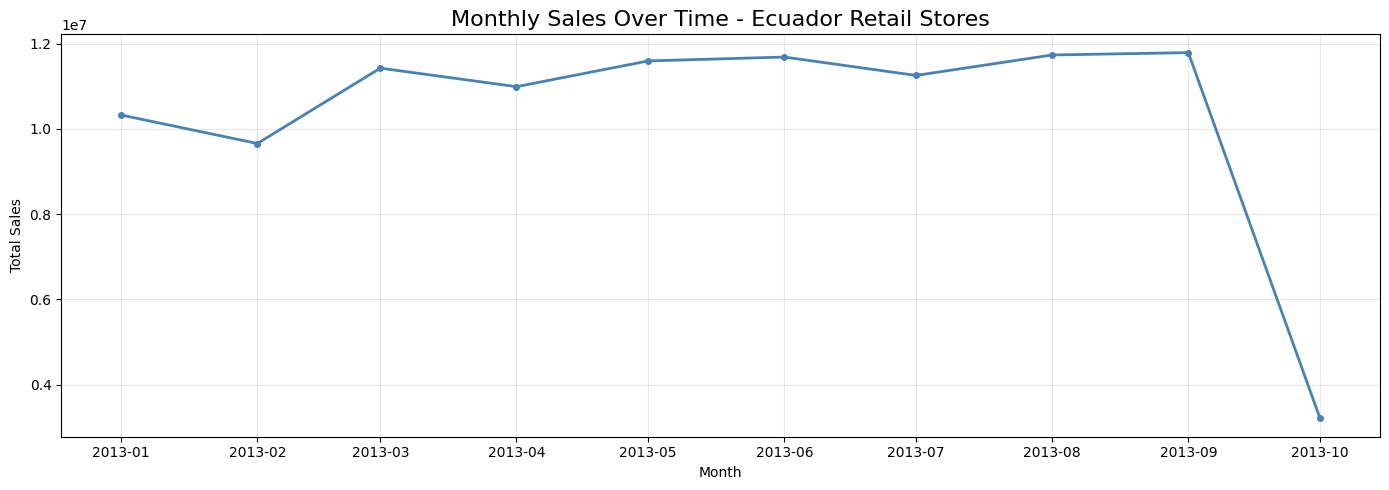

Chart saved!


In [7]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month'], monthly_sales['sales'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Over Time - Ecuador Retail Stores', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('historical_sales.png', dpi=150)
plt.show()
print("Chart saved!")

In [8]:
monthly_sales['Month_Num'] = np.arange(len(monthly_sales))
monthly_sales['Month_of_Year'] = monthly_sales['Month'].dt.month
monthly_sales['Year'] = monthly_sales['Month'].dt.year

print("Features created!")
monthly_sales.head(10)

Features created!


,Month,sales,Month_Num,Month_of_Year,Year
0,2013-01-01,1.032762e+07,0,1,2013
1,2013-02-01,9.658960e+06,1,2,2013
2,2013-03-01,1.142850e+07,2,3,2013
3,2013-04-01,1.099346e+07,3,4,2013
4,2013-05-01,1.159770e+07,4,5,2013
5,2013-06-01,1.168934e+07,5,6,2013
6,2013-07-01,1.125740e+07,6,7,2013
7,2013-08-01,1.173779e+07,7,8,2013
8,2013-09-01,1.179293e+07,8,9,2013
9,2013-10-01,3.203835e+06,9,10,2013


In [9]:
split = int(len(monthly_sales) * 0.8)
train = monthly_sales[:split]
test = monthly_sales[split:]

print(f"Training months: {len(train)}")
print(f"Testing months: {len(test)}")

Training months: 8
Testing months: 2


In [10]:
features = ['Month_Num', 'Month_of_Year', 'Year']

X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 40)
print("       MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"  Mean Absolute Error  (MAE) : {mae:,.2f}")
print(f"  Root Mean Sq. Error (RMSE) : {rmse:,.2f}")
print("=" * 40)
print(f"\nForecast is off by ~{mae:,.0f} units on average per month.")

       MODEL PERFORMANCE RESULTS
  Mean Absolute Error  (MAE) : 4,733,805.40
  Root Mean Sq. Error (RMSE) : 6,469,109.02

Forecast is off by ~4,733,805 units on average per month.


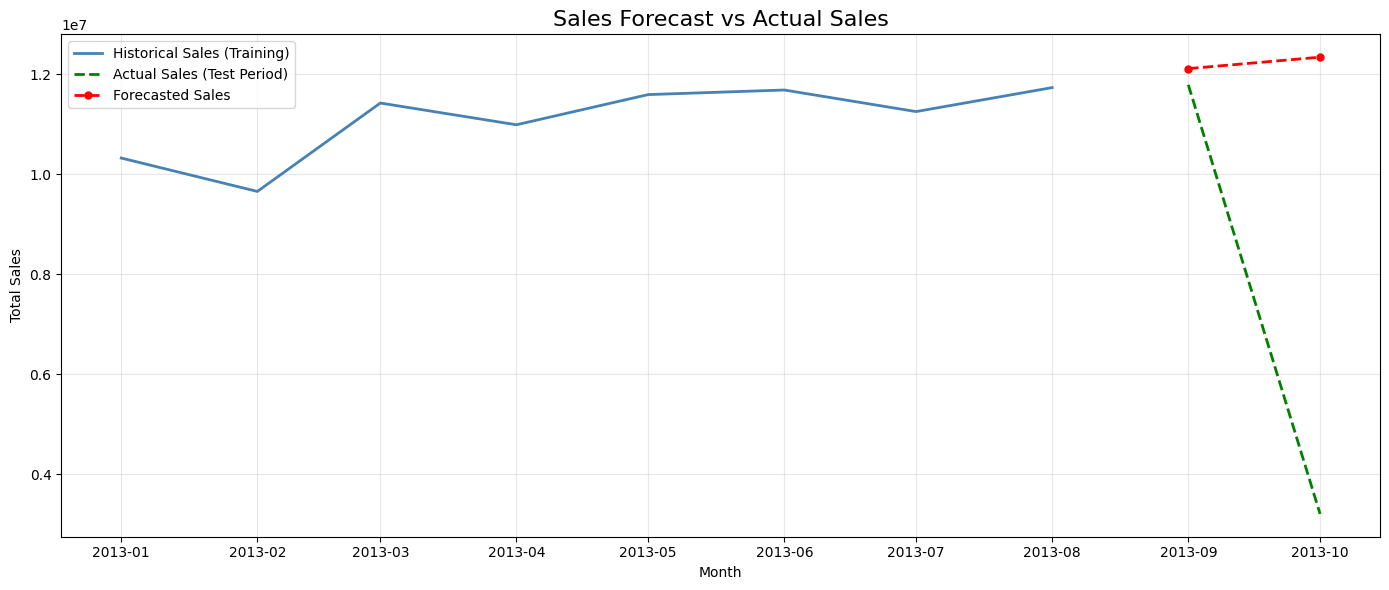

Chart saved!


In [12]:
plt.figure(figsize=(14, 6))
plt.plot(train['Month'], train['sales'],
         label='Historical Sales (Training)', color='steelblue', linewidth=2)
plt.plot(test['Month'], y_test,
         label='Actual Sales (Test Period)', color='green', linewidth=2, linestyle='--')
plt.plot(test['Month'], y_pred,
         label='Forecasted Sales', color='red', linewidth=2, linestyle='--', marker='o', markersize=5)
plt.title('Sales Forecast vs Actual Sales', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_vs_actual.png', dpi=150)
plt.show()
print("Chart saved!")

In [13]:
last_month_num = monthly_sales['Month_Num'].max()
last_date = monthly_sales['Month'].max()

future_months = []
for i in range(1, 7):
    next_date = last_date + pd.DateOffset(months=i)
    future_months.append({
        'Month': next_date,
        'Month_Num': last_month_num + i,
        'Month_of_Year': next_date.month,
        'Year': next_date.year
    })

future_df = pd.DataFrame(future_months)
future_df['Forecasted_Sales'] = model.predict(future_df[features])

print("NEXT 6 MONTHS SALES FORECAST")
print("=" * 40)
for _, row in future_df.iterrows():
    print(f"  {row['Month'].strftime('%B %Y')} : {row['Forecasted_Sales']:,.0f} units")
print("=" * 40)

NEXT 6 MONTHS SALES FORECAST
  November 2013 : 12,575,942 units
  December 2013 : 12,805,110 units
  January 2014 : 11,659,269 units
  February 2014 : 11,888,437 units
  March 2014 : 12,117,605 units
  April 2014 : 12,346,773 units


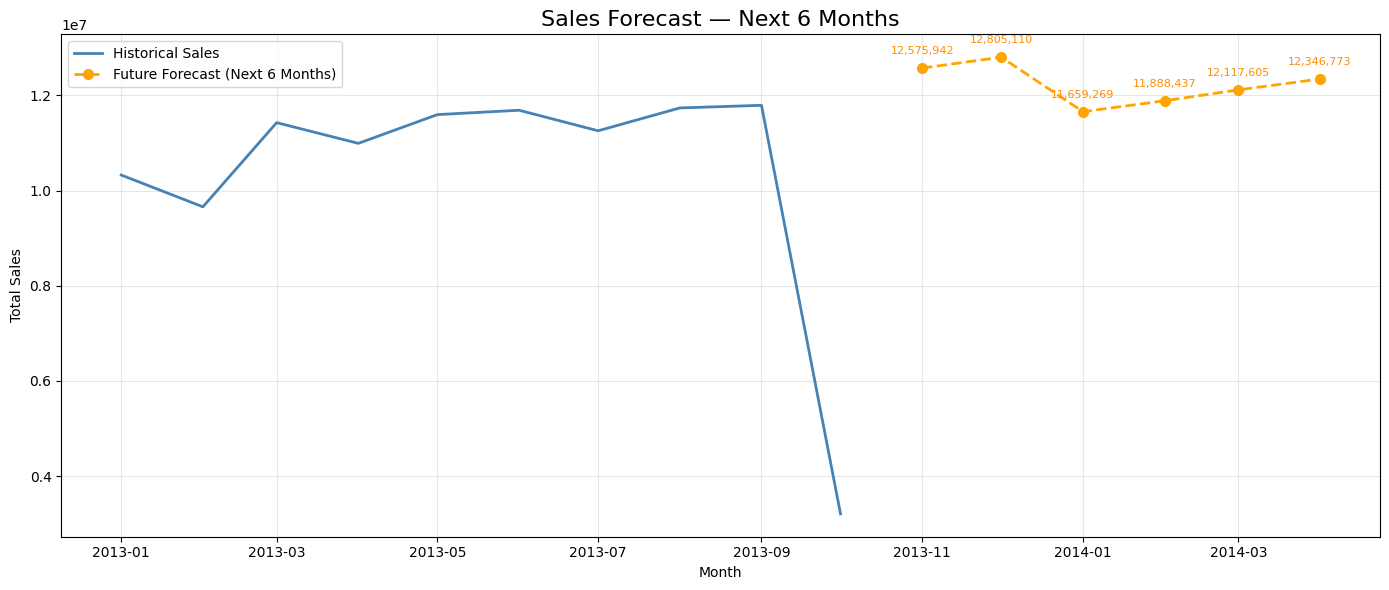

Chart saved!


In [14]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month'], monthly_sales['sales'],
         label='Historical Sales', color='steelblue', linewidth=2)
plt.plot(future_df['Month'], future_df['Forecasted_Sales'],
         label='Future Forecast (Next 6 Months)', color='orange',
         linewidth=2, linestyle='--', marker='o', markersize=7)

for _, row in future_df.iterrows():
    plt.annotate(f"{row['Forecasted_Sales']:,.0f}",
                xy=(row['Month'], row['Forecasted_Sales']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='darkorange')

plt.title('Sales Forecast — Next 6 Months', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()
print("Chart saved!")

In [15]:
avg_forecast = future_df['Forecasted_Sales'].mean()
total_forecast = future_df['Forecasted_Sales'].sum()
best_month = future_df.loc[future_df['Forecasted_Sales'].idxmax()]
slow_month = future_df.loc[future_df['Forecasted_Sales'].idxmin()]

print("=" * 50)
print("        BUSINESS INSIGHTS SUMMARY")
print("=" * 50)
print(f"\n  Forecast Period  : Next 6 Months")
print(f"  Total Sales      : {total_forecast:,.0f} units")
print(f"  Monthly Average  : {avg_forecast:,.0f} units")
print(f"  Best Month       : {best_month['Month'].strftime('%B %Y')} ({best_month['Forecasted_Sales']:,.0f} units)")
print(f"  Slowest Month    : {slow_month['Month'].strftime('%B %Y')} ({slow_month['Forecasted_Sales']:,.0f} units)")
print("\n  RECOMMENDATIONS:")
print(f"  - Stock up inventory before {best_month['Month'].strftime('%B %Y')}")
print(f"  - Run promotions in {slow_month['Month'].strftime('%B %Y')} to boost sales")
print(f"  - Plan staffing for peak demand period")
print("=" * 50)

        BUSINESS INSIGHTS SUMMARY

  Forecast Period  : Next 6 Months
  Total Sales      : 73,393,136 units
  Monthly Average  : 12,232,189 units
  Best Month       : December 2013 (12,805,110 units)
  Slowest Month    : January 2014 (11,659,269 units)

  RECOMMENDATIONS:
  - Stock up inventory before December 2013
  - Run promotions in January 2014 to boost sales
  - Plan staffing for peak demand period


In [20]:
print(""" SALES FORECAST REPORT- ECUADOR RETAIL STORES:

This model was trained on over 3 years of real retail sales data from stores across Ecuador. It identified recurring
monthly patterns and year over year growth trends to generate predictions for the next 6 months. The forecast reflects what
sales are likely to look like based on how they have behaved historically.

From a Business Standpoint: The forecast provides a data driven basis for operational planning.
Inventory orders can be aligned with predicted demand to avoid both shortages and excess stock. Staffing
levels can be adjusted ahead of high demand periods rather than reactively. Marketing budgets can be directed toward
slower months to offset the dip in natural demand. On the financial side, the predicted monthly figures serve as a
baseline for revenue planning and expense management.

Algorithm: Linear Regression
Training: 80% historical data for training, & 20% for testing
Data source: Kaggle Store Sales Time Series Forecasting """)

 SALES FORECAST REPORT- ECUADOR RETAIL STORES:

This model was trained on over 3 years of real retail sales data from stores across Ecuador. It identified recurring
monthly patterns and year over year growth trends to generate predictions for the next 6 months. The forecast reflects what
sales are likely to look like based on how they have behaved historically.

From a Business Standpoint: The forecast provides a data driven basis for operational planning.
Inventory orders can be aligned with predicted demand to avoid both shortages and excess stock. Staffing
levels can be adjusted ahead of high demand periods rather than reactively. Marketing budgets can be directed toward
slower months to offset the dip in natural demand. On the financial side, the predicted monthly figures serve as a
baseline for revenue planning and expense management.

Algorithm: Linear Regression
Training: 80% historical data for training, & 20% for testing
Data source: Kaggle Store Sales Time Series Forecasting 